In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [15]:
#Load Dataset
data = pd.read_csv("C:/Users/jagdi/OneDrive/Pictures/resume/fund_dataset.csv")
data

,MarketCap,Type,Risk,SharpeRatio,1YrReturn%,3YrReturn%
0,Small,Hybrid,Low,0.94,10.39,8.28
1,Large,Equity,High,0.41,10.19,12.42
2,Small,Equity,Low,1.31,12.96,23.95
3,Small,Equity,High,1.78,17.21,26.29
4,Large,Equity,Low,1.38,16.18,24.44
...,...,...,...,...,...,...
295,Mid,Equity,Moderate,1.82,16.31,20.18
296,Mid,Hybrid,Low,2.29,12.49,13.25
297,Mid,Equity,Moderate,1.64,13.82,10.91
298,Mid,Hybrid,Moderate,0.97,7.86,11.67


In [17]:
# Display first few rows
print("Dataset Preview:")
print(data.head())

Dataset Preview:
  MarketCap    Type  Risk  SharpeRatio  1YrReturn%  3YrReturn%
0     Small  Hybrid   Low         0.94       10.39        8.28
1     Large  Equity  High         0.41       10.19       12.42
2     Small  Equity   Low         1.31       12.96       23.95
3     Small  Equity  High         1.78       17.21       26.29
4     Large  Equity   Low         1.38       16.18       24.44


In [19]:
# Remove rows with missing values in required columns
required_cols = [
    'MarketCap', 'Type', 'Risk',
    'SharpeRatio', '1YrReturn%', '3YrReturn%'
]

data = data[required_cols].dropna()

print("\nData cleaned successfully!")



Data cleaned successfully!


In [21]:

# Group data and calculate mean 3YrReturn%
grouped = (
    data
    .groupby(['MarketCap', 'Type', 'Risk'])['3YrReturn%']
    .mean()
    .reset_index()
)

In [23]:
best_combination = grouped.loc[grouped['3YrReturn%'].idxmax()]

print("\nBest Combination for Maximum 3Yr Return:")
print(best_combination)


Best Combination for Maximum 3Yr Return:
MarketCap           Mid
Type             Hybrid
Risk                Low
3YrReturn%    24.467143
Name: 16, dtype: object


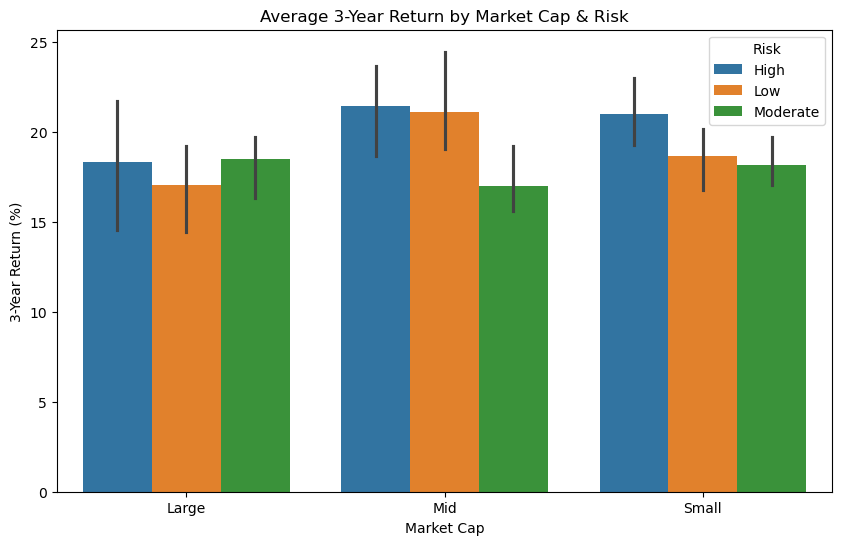

In [25]:
# Visualization – Problem 1
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped,
    x='MarketCap',
    y='3YrReturn%',
    hue='Risk'
)
plt.title("Average 3-Year Return by Market Cap & Risk")
plt.xlabel("Market Cap")
plt.ylabel("3-Year Return (%)")
plt.show()

In [33]:
#PROBLEM 2:Ideal Sharpe Ratio to Maximize 1Yr Return
X = data[['SharpeRatio']]
y = data['1YrReturn%']


In [35]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

sharpe_range = np.linspace(X.min(), X.max(), 100)
sharpe_range_poly = poly.transform(sharpe_range)

predicted_returns = model.predict(sharpe_range_poly)

optimal_index = np.argmax(predicted_returns)
optimal_sharpe = sharpe_range[optimal_index][0]
max_return = predicted_returns[optimal_index]

print("\nOptimal Sharpe Ratio for Maximum 1Yr Return:")
print(f"Sharpe Ratio: {optimal_sharpe:.2f}")
print(f"Expected 1Yr Return: {max_return:.2f}%")



# Visualization – Problem 2

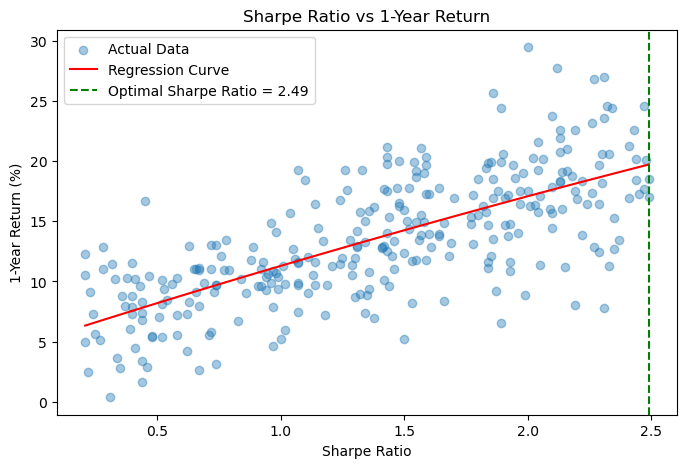

In [41]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.4, label="Actual Data")
plt.plot(sharpe_range, predicted_returns, color='red', label="Regression Curve")
plt.axvline(optimal_sharpe, linestyle='--', color='green',
            label=f'Optimal Sharpe Ratio = {optimal_sharpe:.2f}')

plt.title("Sharpe Ratio vs 1-Year Return")
plt.xlabel("Sharpe Ratio")
plt.ylabel("1-Year Return (%)")
plt.legend()
plt.show()

# FINAL INSIGHTS

In [43]:
print("\nFinal Insights:")
print("1. Diversification across MarketCap, Type, and Risk significantly impacts long-term returns.")
print("2. Sharpe Ratio has a non-linear relationship with short-term returns.")
print("3. Very high Sharpe Ratios may not always lead to higher returns due to risk-return tradeoffs.")


Final Insights:
1. Diversification across MarketCap, Type, and Risk significantly impacts long-term returns.
2. Sharpe Ratio has a non-linear relationship with short-term returns.
3. Very high Sharpe Ratios may not always lead to higher returns due to risk-return tradeoffs.
